
**Pré-Processamento**
---



In [1]:
!pip -q install plotly --upgrade
!pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 82.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


**Importando bibliotecas**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
from sklearn.impute import KNNImputer

**Abrindo um arquivo CSV do drive**

In [4]:
base = pd.read_csv('/content/sample_data/airlines_reviews.csv', sep=',', usecols=[ 'Airline', 'Verified', 'Type of Traveller', 'Month Flown', 'Route', 'Class', 'Seat Comfort',
                                                                                  'Staff Service', 'Food & Beverages', 'Inflight Entertainment', 'Value For Money', 'Overall Rating', 'Recommended'
])


In [5]:
base

,Airline,Verified,Type of Traveller,Month Flown,Route,Class,Seat Comfort,Staff Service,Food & Beverages,Inflight Entertainment,Value For Money,Overall Rating,Recommended
0,Singapore Airlines,True,Solo Leisure,December 2023,Jakarta to Singapore,Business Class,4,4,4,4,4,9,yes
1,Singapore Airlines,True,Solo Leisure,February 2024,Phuket to Singapore,Economy Class,5,3,4,4,1,3,no
2,Singapore Airlines,True,Family Leisure,February 2024,Siem Reap to Singapore,Economy Class,1,5,2,1,5,10,yes
3,Singapore Airlines,True,Solo Leisure,February 2024,Singapore to London Heathrow,Economy Class,5,5,5,5,5,10,yes
4,Singapore Airlines,True,Family Leisure,February 2024,Singapore to Phnom Penh,Economy Class,5,5,5,5,5,10,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8095,Korean Air,True,Business,June 2016,BNE to ULN via ICN,Economy Class,5,4,5,3,4,7,yes
8096,Korean Air,False,Couple Leisure,June 2016,SYD to LHR via ICN,Economy Class,3,5,5,4,5,10,yes
8097,Korean Air,True,Business,April 2016,DPS to ICN,Business Class,4,5,5,5,1,2,no
8098,Korean Air,False,Business,April 2016,ICN to CDG,Business Class,5,1,3,4,5,10,yes


In [6]:
import numpy as np

In [7]:
MAX_CATS_PLOT = 30
NUM_BINS = 30

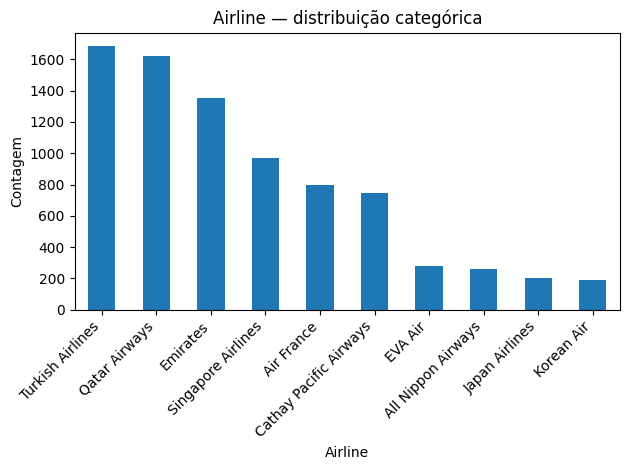

/tmp/ipython-input-896712761.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


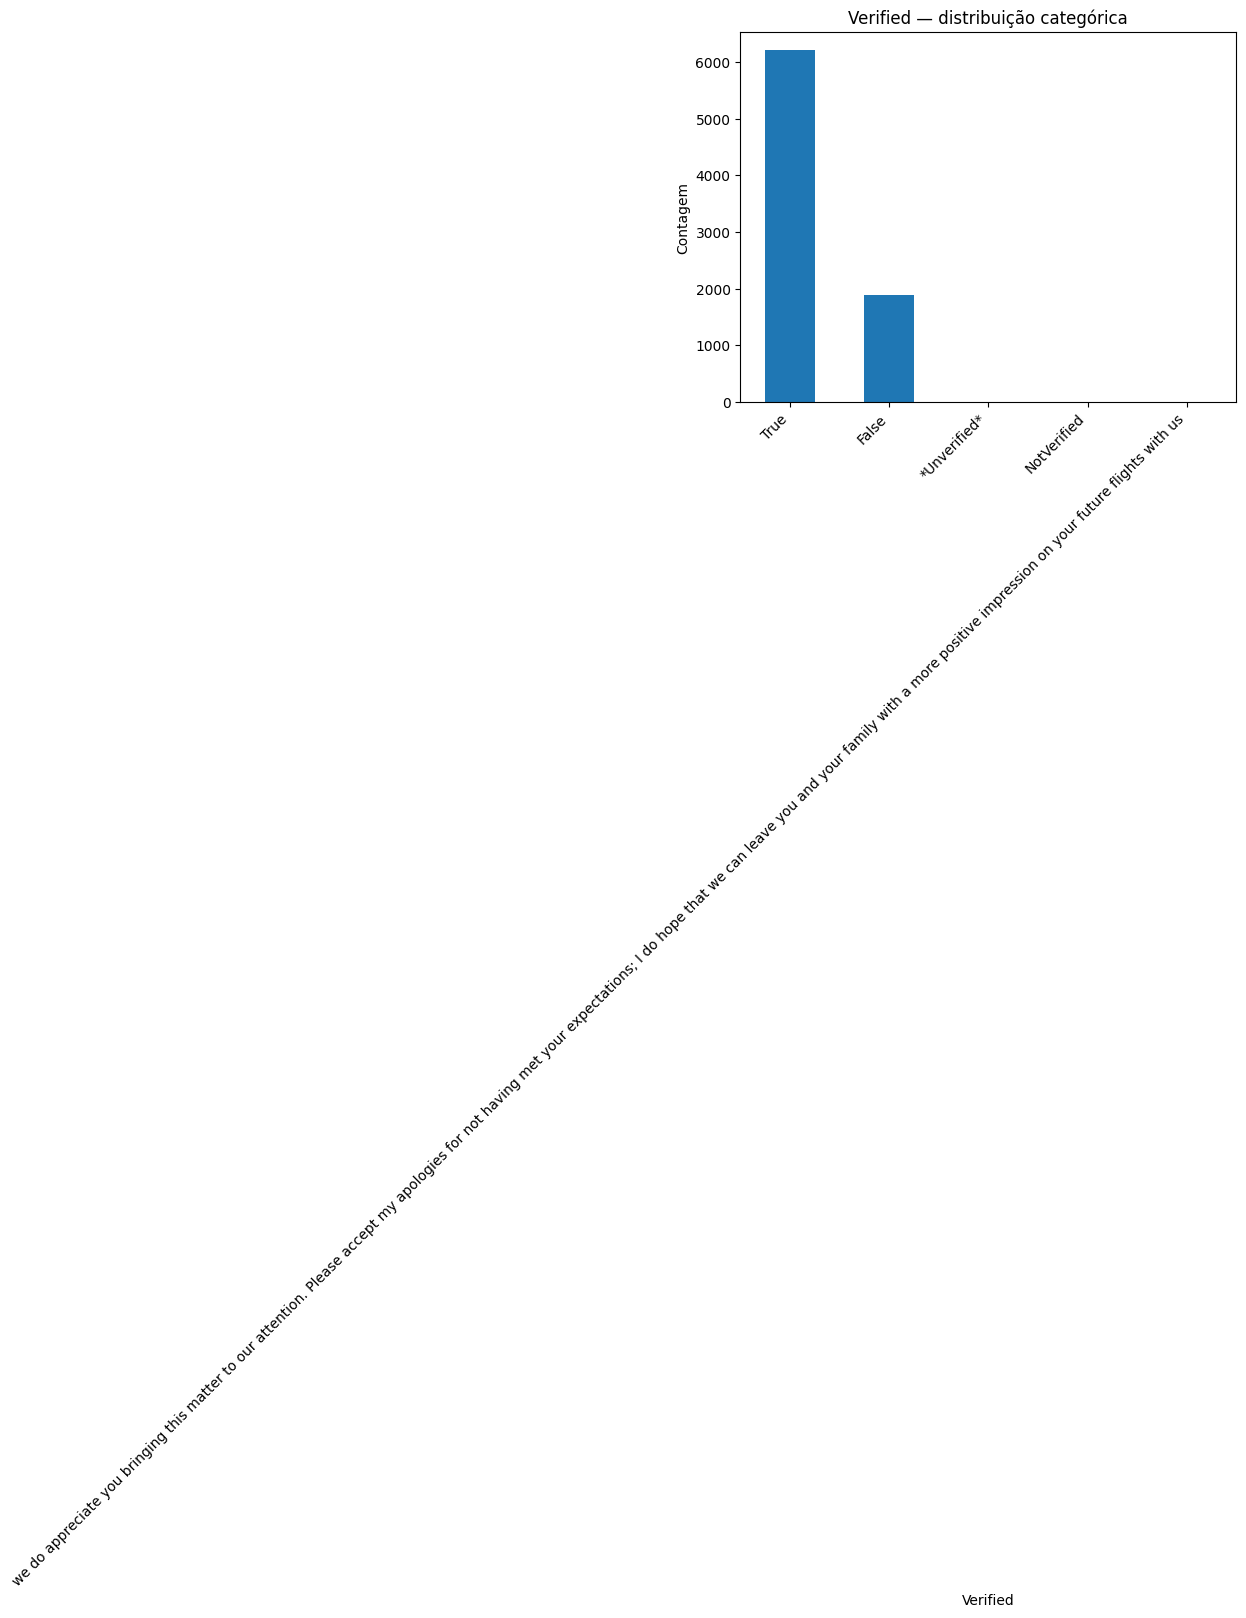

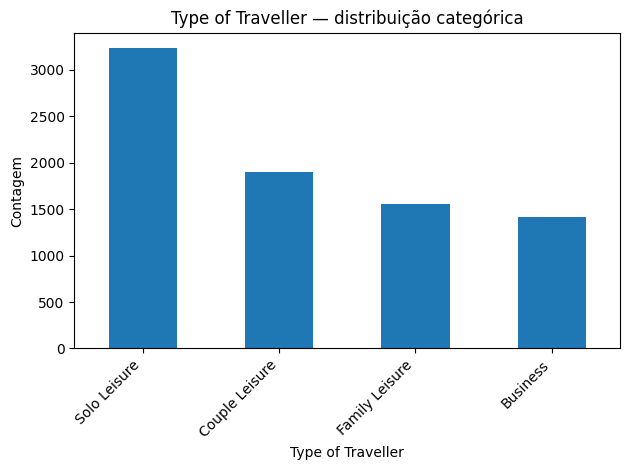

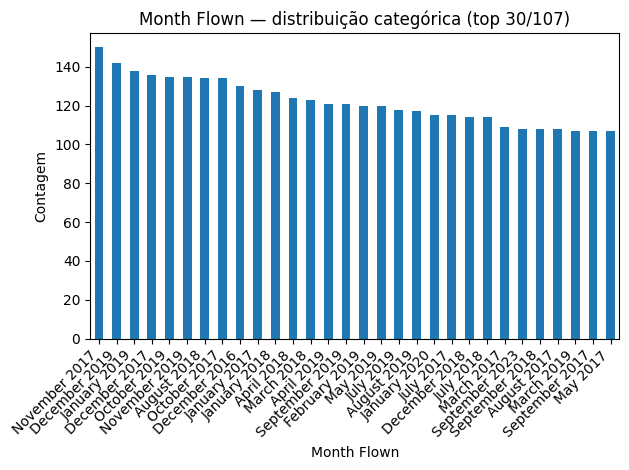

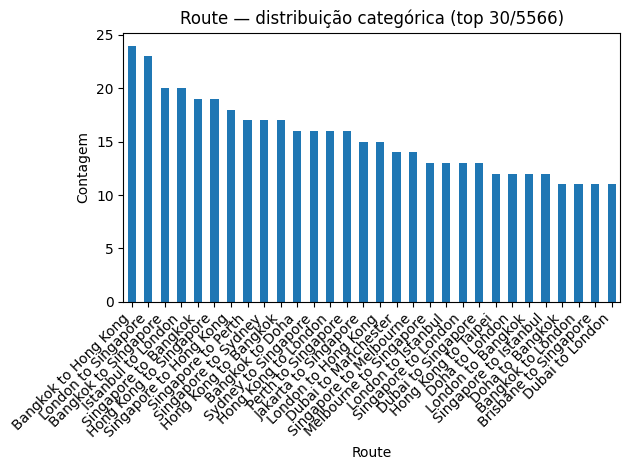

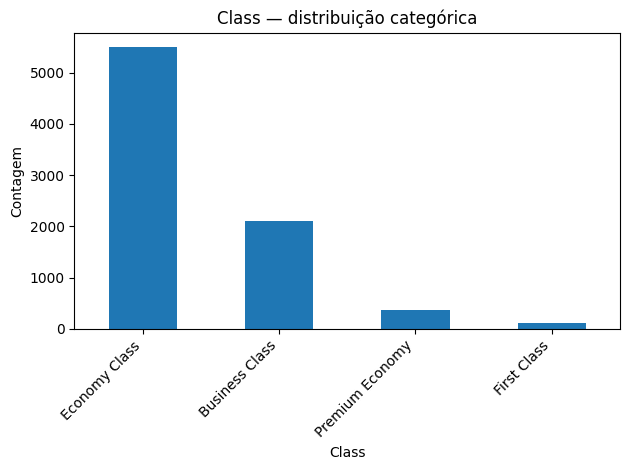

/tmp/ipython-input-896712761.py:4: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(s) or


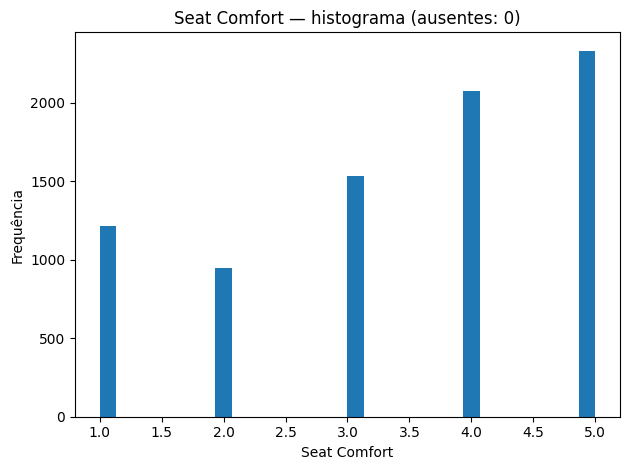

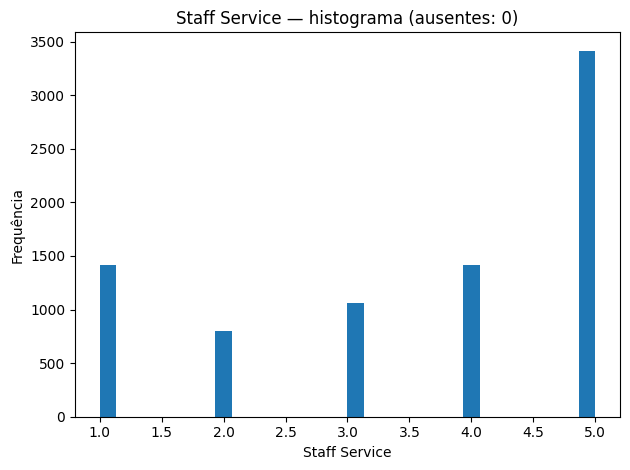

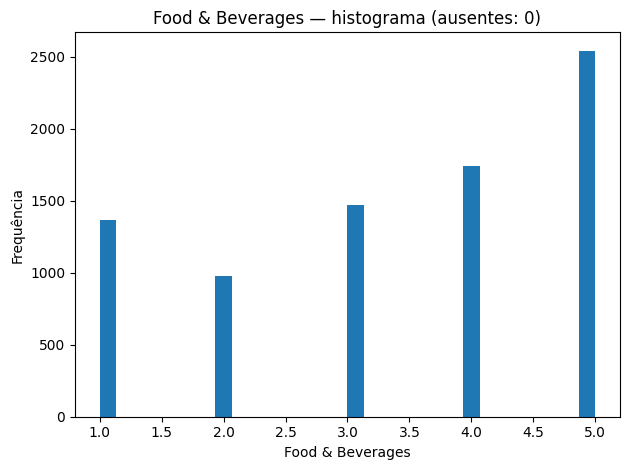

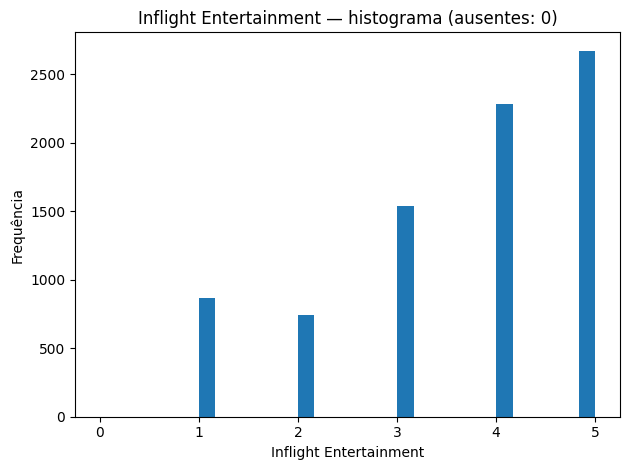

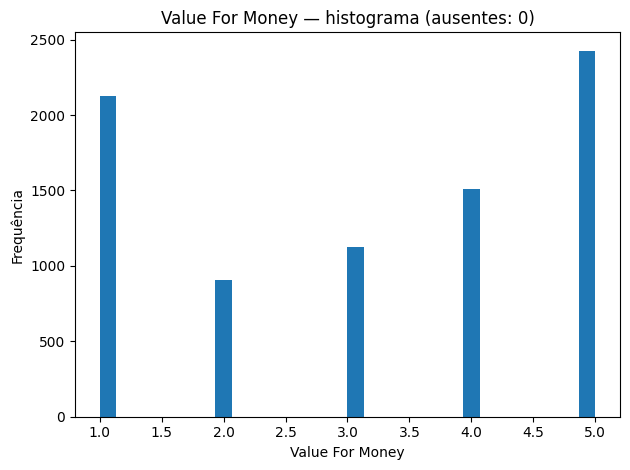

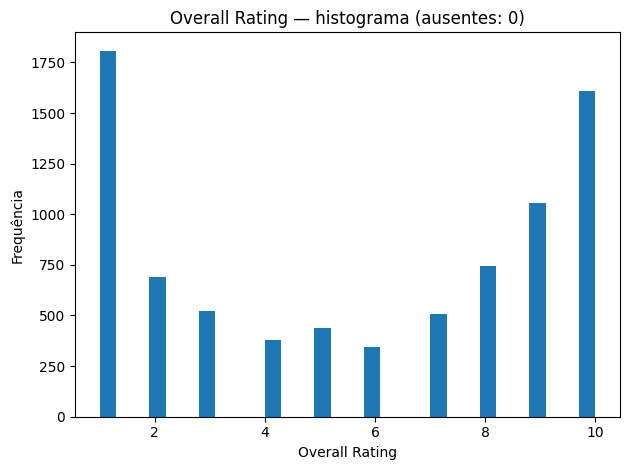

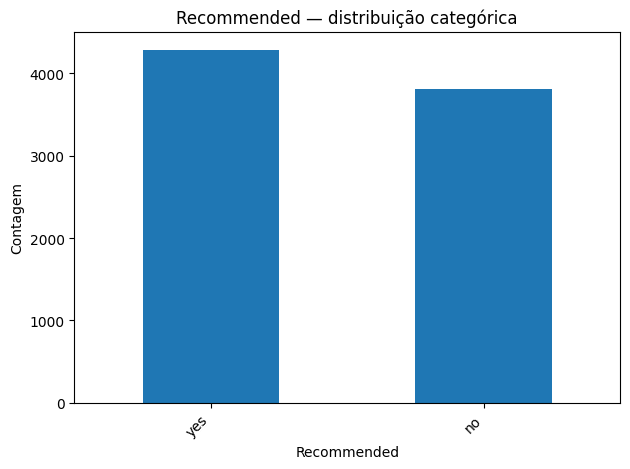

In [8]:
def is_categorical_like(s: pd.Series) -> bool:
    return (s.dtype == "O" or
            pd.api.types.is_string_dtype(s) or
            pd.api.types.is_categorical_dtype(s) or
            pd.api.types.is_bool_dtype(s))

for col in base.columns:
    s = base[col]
    plt.figure()
    if is_categorical_like(s):
        vc = s.fillna("Em branco").value_counts(dropna=False)
        if len(vc) > MAX_CATS_PLOT:
            vc = vc.head(MAX_CATS_PLOT)
            title_extra = f" (top {len(vc)}/{s.nunique(dropna=False)})"
        else:
            title_extra = ""
        vc.plot(kind="bar")
        plt.ylabel("Contagem")
        plt.xlabel(col)
        plt.title(f"{col} — distribuição categórica{title_extra}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        s_numeric = pd.to_numeric(s, errors="coerce")
        n_miss = s_numeric.isna().sum()
        s_numeric = s_numeric.dropna()
        plt.hist(s_numeric, bins=NUM_BINS)
        plt.xlabel(col)
        plt.ylabel("Frequência")
        plt.title(f"{col} — histograma (ausentes: {n_miss})")
        plt.tight_layout()
        plt.show()

**Verificando se tem ausência de dados**

In [9]:
base.isnull()

,Airline,Verified,Type of Traveller,Month Flown,Route,Class,Seat Comfort,Staff Service,Food & Beverages,Inflight Entertainment,Value For Money,Overall Rating,Recommended
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8095,False,False,False,False,False,False,False,False,False,False,False,False,False
8096,False,False,False,False,False,False,False,False,False,False,False,False,False
8097,False,False,False,False,False,False,False,False,False,False,False,False,False
8098,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
np.unique(base['Recommended'], return_counts=True)

(array(['no', 'yes'], dtype=object), array([3813, 4287]))

In [11]:
base.isnull().sum()

,0
Airline,0
Verified,0
Type of Traveller,0
Month Flown,0
Route,0
Class,0
Seat Comfort,0
Staff Service,0
Food & Beverages,0
Inflight Entertainment,0


**Verificando amostras inconsistentes e redundantes**

In [12]:
import pandas as pd

coluna_alvo = 'Recommended'

Nome_das_Colunas = base.columns.drop(coluna_alvo)

print(f"Total de amostras iniciais: {base.shape[0]}")
print(f"Coluna alvo: {coluna_alvo}")
print(f"Total de features consideradas: {len(Nome_das_Colunas)}")

def delDuplicatas(df_dataset):
    '''
    Para cada grupo de amostras duplicadas, mantém uma e apaga as demais
    '''
    tamanho_antes = len(df_dataset)
    df_dataset = df_dataset.drop_duplicates(keep='first')
    removidas = tamanho_antes - len(df_dataset)
    print(f"Redundâncias removidas: {removidas}")
    return df_dataset

def delInconsistencias(df_dataset, features):
    '''
    Remove todas as amostras inconsistentes da base de dados
    '''
    tamanho_antes = len(df_dataset)
    df_dataset = df_dataset.drop_duplicates(subset=features, keep=False)
    removidas = tamanho_antes - len(df_dataset)
    print(f"Inconsistências removidas: {removidas}")
    return df_dataset

# --- EXECUÇÃO ---

print("\n--- 1. LIMPEZA DE REDUNDÂNCIA ---")
base = delDuplicatas(base)

print("\n--- 2. LIMPEZA DE INCONSISTÊNCIA ---")
base = delInconsistencias(base, Nome_das_Colunas)

print("\n--- RESULTADO FINAL ---")
print(f"Formato final da base: {base.shape}")

# Verificação de segurança
verificacao = base[base.duplicated(subset=Nome_das_Colunas, keep=False)]
if verificacao.empty:
    print("Sucesso: Base limpa e consistente.")
else:
    print("Ainda restaram inconsistências.")

Total de amostras iniciais: 8100
Coluna alvo: Recommended
Total de features consideradas: 12

--- 1. LIMPEZA DE REDUNDÂNCIA ---
Redundâncias removidas: 0

--- 2. LIMPEZA DE INCONSISTÊNCIA ---
Inconsistências removidas: 0

--- RESULTADO FINAL ---
Formato final da base: (8100, 13)
Sucesso: Base limpa e consistente.


In [13]:
np.unique(base['Recommended'], return_counts=True)

(array(['no', 'yes'], dtype=object), array([3813, 4287]))

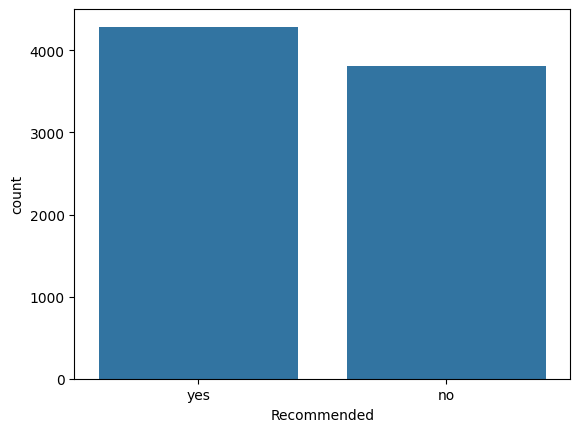

In [14]:
sns.countplot(x = base['Recommended']);

**Verificando outliers**

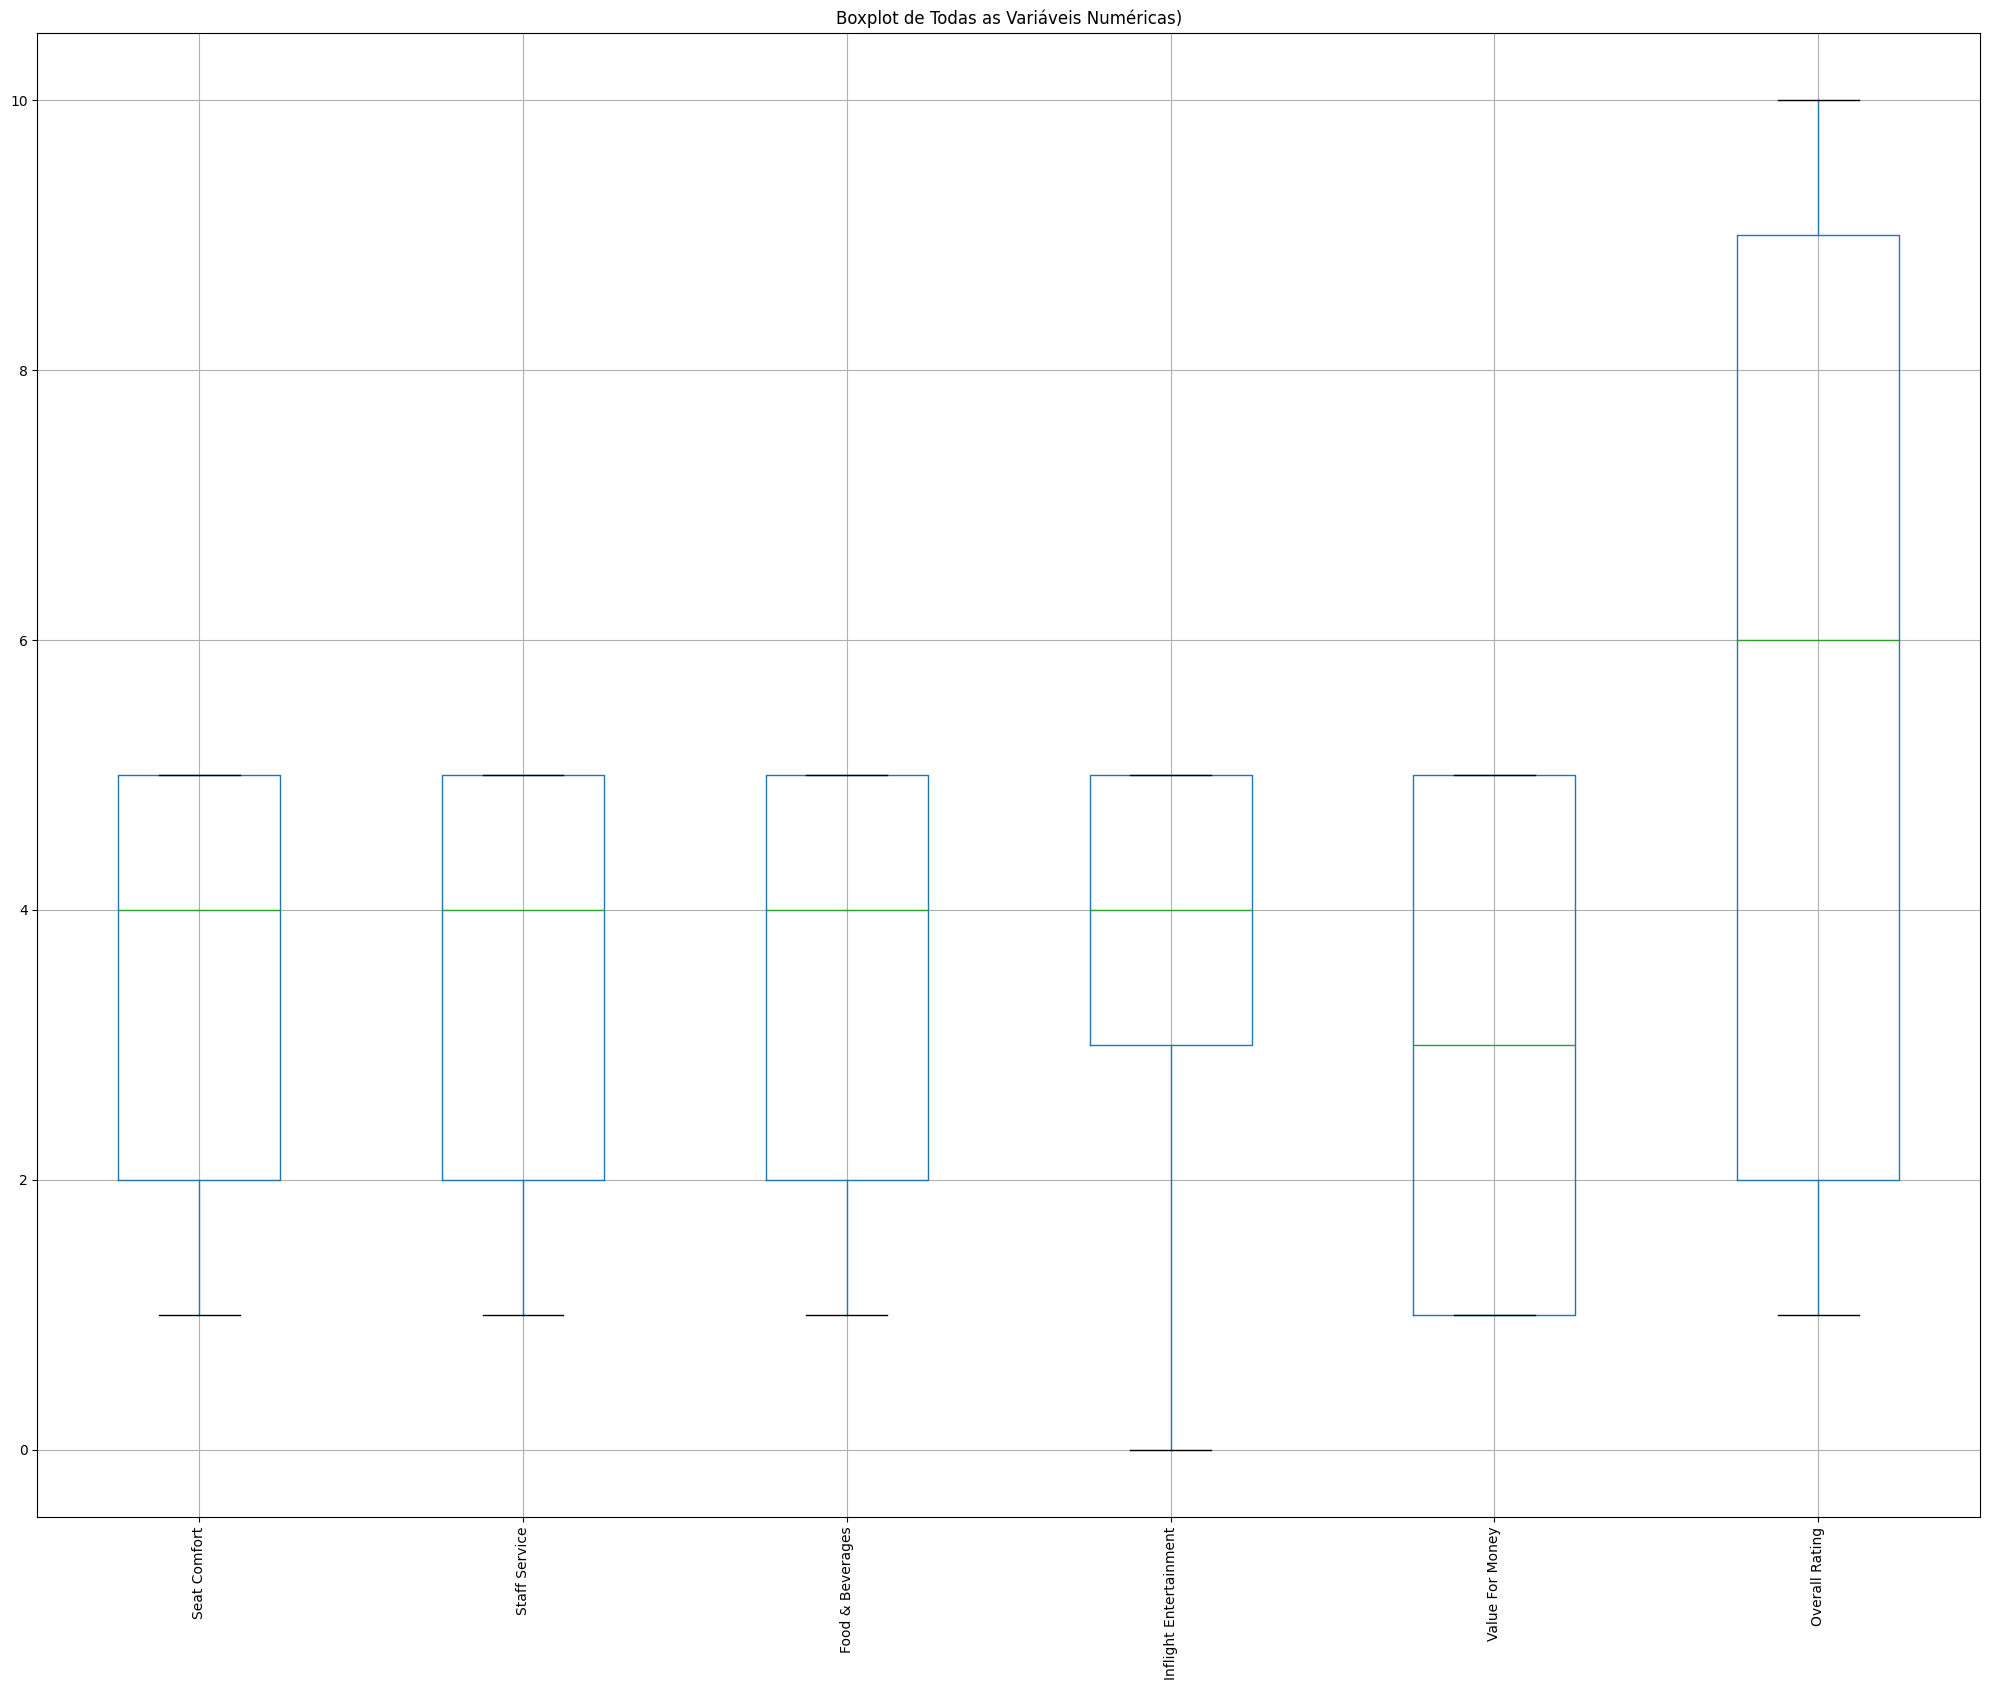

In [15]:
numerical_cols = base.select_dtypes(include=np.number).columns.tolist()

base[numerical_cols].boxplot(figsize=(20,17))
plt.title('Boxplot de Todas as Variáveis Numéricas)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Transformação de atributos binarios**

In [16]:
# colunas binárias que possuem "Sim" e "Não"
base['Verified'] = base['Verified'].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

In [17]:
print(f"Unique values in 'Class' before mapping: {base['Class'].unique()}")

map_class = {
    'First Class': 1,
    'Business Class': 2,
    'Premium Economy': 3,
    'Economy Class': 4
}
base['Class'] = base['Class'].map(map_class)

base['Class'] = base['Class'].fillna(0).astype(int)

print(f"Unique values in 'Class' after mapping and filling NaNs: {base['Class'].unique()}")

Unique values in 'Class' before mapping: ['Business Class' 'Economy Class' 'Premium Economy' 'First Class']
Unique values in 'Class' after mapping and filling NaNs: [2 4 3 1]


In [18]:
# Meses de maior demanda
def categorizar_demanda(mes):
    if mes in [11, 12, 1]:
        return 1 # Alta
    else:
        return 0 # Normal
base['Month Flown'] = pd.to_datetime(base['Month Flown'], format='%B %Y')

base['Month Flown'] = base['Month Flown'].dt.month.apply(categorizar_demanda)

**Transformação de Atributos Categóricos**

In [19]:
categorical_cols_to_onehot = [
    'Airline',
    'Route',
    'Type of Traveller'
]

base = pd.get_dummies(base, columns=categorical_cols_to_onehot, drop_first=True, dtype=int)

print(f"Shape of base after one-hot encoding: {base.shape}")
print("Original categorical columns that were expanded:")
for col in categorical_cols_to_onehot:
    print(f"- {col}")

Shape of base after one-hot encoding: (8100, 5587)
Original categorical columns that were expanded:
- Airline
- Route
- Type of Traveller


In [20]:
base

,Verified,Month Flown,Class,Seat Comfort,Staff Service,Food & Beverages,Inflight Entertainment,Value For Money,Overall Rating,Recommended,...,Route_İstanbul to Berlin,Route_İstanbul to Frankfurt,Route_İstanbul to Hamburg,Route_İstanbul to Islamabad,Route_İstanbul to Izmir,Route_İstanbul to Tel Aviv-Yafo,Route_İzmir to İstanbul,Type of Traveller_Couple Leisure,Type of Traveller_Family Leisure,Type of Traveller_Solo Leisure
0,0,1,2,4,4,4,4,4,9,yes,...,0,0,0,0,0,0,0,0,0,1
1,0,0,4,5,3,4,4,1,3,no,...,0,0,0,0,0,0,0,0,0,1
2,0,0,4,1,5,2,1,5,10,yes,...,0,0,0,0,0,0,0,0,1,0
3,0,0,4,5,5,5,5,5,10,yes,...,0,0,0,0,0,0,0,0,0,1
4,0,0,4,5,5,5,5,5,10,yes,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8095,0,0,4,5,4,5,3,4,7,yes,...,0,0,0,0,0,0,0,0,0,0
8096,0,0,4,3,5,5,4,5,10,yes,...,0,0,0,0,0,0,0,1,0,0
8097,0,0,2,4,5,5,5,1,2,no,...,0,0,0,0,0,0,0,0,0,0
8098,0,0,2,5,1,3,4,5,10,yes,...,0,0,0,0,0,0,0,0,0,0


**Dividir conjunto de treino e teste**

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_prev = base.drop('Recommended', axis=1)

In [23]:
y_classe = base['Recommended'].values

In [24]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X_prev, y_classe,
                                                      test_size=0.20,
                                                      random_state=42,
                                                      stratify=y_classe)

**Normalizar dado numérico**

In [25]:
from sklearn.preprocessing import MinMaxScaler

In [26]:
scaler = MinMaxScaler()
cols_to_scale = ['Seat Comfort', 'Staff Service', 'Food & Beverages', 'Inflight Entertainment', 'Value For Money', 'Overall Rating']
X_treino[cols_to_scale] = scaler.fit_transform(X_treino[cols_to_scale])
X_teste[cols_to_scale] = scaler.transform(X_teste[cols_to_scale])

print("Normalização concluída sem vazamento de dados!")

Normalização concluída sem vazamento de dados!


**Testar com Random Forest**

In [27]:
from sklearn.ensemble import RandomForestClassifier
modelo = RandomForestClassifier(n_estimators=100, max_features=6, criterion='gini', random_state = 42)
modelo.fit(X_treino, y_treino)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",6
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [28]:
previsoes = modelo.predict(X_teste)

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_score(y_teste,previsoes)

0.9382716049382716

In [30]:
from yellowbrick.classifier import ConfusionMatrix
confusion_matrix(y_teste, previsoes)

array([[713,  50],
       [ 50, 807]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.9382716049382716

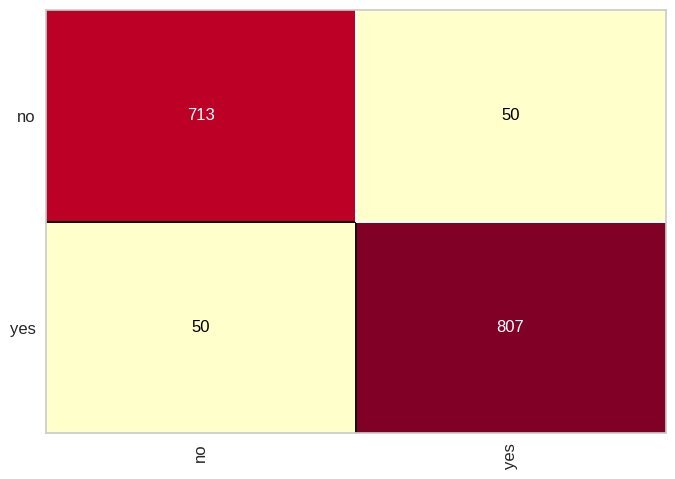

In [38]:
from yellowbrick.classifier import ConfusionMatrix

cm = ConfusionMatrix(modelo, force_model=True)
cm.fit(X_treino, y_treino)
cm.score(X_teste, y_teste)

In [39]:
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

          no       0.93      0.93      0.93       763
         yes       0.94      0.94      0.94       857

    accuracy                           0.94      1620
   macro avg       0.94      0.94      0.94      1620
weighted avg       0.94      0.94      0.94      1620



**Treinamento somente com atributos textuais**

In [40]:
atributos_texto = pd.read_csv('/content/sample_data/airlines_reviews.csv', sep=',', usecols=['Title', 'Reviews', 'Recommended'])

**Pré-Processar Texto**

In [41]:
import nltk
from nltk.corpus import stopwords
import string
import re

In [42]:
from nltk.corpus import stopwords

from nltk.tokenize import word_tokenize

from nltk.stem import WordNetLemmatizer

import nltk

nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [43]:
# Tratar texto
def preprocess_text(text):
    # Remover pontuação
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # transformar texto em token
    tokens = word_tokenize(text.lower())

    # Remover stop words
    filtered_tokens = [token for token in tokens if token not in stopwords.words('english')]

    # Lematizar tokens

    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]

    # TOken -> string
    processed_text = ' '.join(lemmatized_tokens)

    return processed_text

In [44]:
atributos_texto['Title'] = atributos_texto['Title'].apply(preprocess_text)

In [45]:
atributos_texto['Reviews'] = atributos_texto['Reviews'].apply(preprocess_text)

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

# Juntar Título e Review
atributos_texto['texto_limpo'] = atributos_texto['Title'].astype(str) + " " + atributos_texto['Reviews'].astype(str)

In [47]:
# Para o proximo treinamento
base['Texto_Completo'] = atributos_texto['Title'].astype(str) + " " + atributos_texto['Reviews'].astype(str)

In [48]:
colunas_para_remover = ['Title', 'Reviews', 'Recommended']
X = atributos_texto.drop(colunas_para_remover, axis=1)

In [49]:
y_classe = atributos_texto['Recommended'].values

In [50]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y_classe,
                                                      test_size=0.20,
                                                      random_state=42,
                                                      stratify=y_classe)

In [51]:
print("Tamanho do Treino:", X_treino.shape)
print("Tamanho do Teste:", X_teste.shape)

Tamanho do Treino: (6480, 1)
Tamanho do Teste: (1620, 1)


**Processamento do texto**

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    min_df=5  # Ignora palavras que aparecem em menos de 5 documentos (reduz ruído)
)

texto_treino_tfidf = tfidf.fit_transform(X_treino['texto_limpo'])
texto_teste_tfidf = tfidf.transform(X_teste['texto_limpo'])

print(f"Shape do Texto TF-IDF: {texto_treino_tfidf.shape}")

Shape do Texto TF-IDF: (6480, 1000)


In [55]:
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression

X_treino = X_treino.drop(columns=['texto_limpo'], errors='ignore')
X_teste = X_teste.drop(columns=['texto_limpo'], errors='ignore')

X_treino_final = hstack([texto_treino_tfidf, X_treino])
X_teste_final = hstack([texto_teste_tfidf, X_teste])

model_log = LogisticRegression(max_iter=1000, random_state=42)
model_log.fit(X_treino_final, y_treino)

tfidf_feature_names = tfidf.get_feature_names_out()

numerical_categorical_feature_names = X_treino.columns.tolist()

nomes_features = list(tfidf_feature_names) + numerical_categorical_feature_names

# Criar tabela de importância
df_pesos = pd.DataFrame({
    'Atributo': nomes_features,
    'Peso': model_log.coef_[0]
})

# Exibir
print("--- TOP 20 RECOMENDA (Pesos positivos) ---")
print(df_pesos.sort_values(by='Peso', ascending=False).head(20))

print("\n--- TOP 20 NÃO RECOMENDA (Pesos negativos) ---")
print(df_pesos.sort_values(by='Peso', ascending=True).head(20))

--- TOP 20 RECOMENDA (Pesos positivos) ---
         Atributo      Peso
315     excellent  5.391943
394          good  4.540165
396         great  3.698956
111          best  3.480866
375      friendly  3.425336
660      pleasant  3.174613
878         thank  3.153700
200   comfortable  3.078990
48        amazing  3.012895
84      attentive  2.732574
418       helpful  2.726942
252     delicious  2.594163
592          nice  2.510512
294     efficient  2.497193
687  professional  2.425476
645       perfect  2.353205
625       overall  2.301912
338     fantastic  2.299395
983     wonderful  2.248830
190         clean  2.182561

--- TOP 20 NÃO RECOMENDA (Pesos negativos) ---
          Atributo      Peso
991          worst -4.029198
667           poor -3.805330
876       terrible -3.598197
98             bad -3.016584
892           told -2.614354
756           rude -2.488510
236       customer -2.468628
272  disappointing -2.420718
427       horrible -2.409089
271   disappointed -2.334626
99

In [56]:
print(f"Shape Final Treino: {X_treino_final.shape}")
print(f"Shape Final Teste: {X_teste_final.shape}")

Shape Final Treino: (6480, 1000)
Shape Final Teste: (1620, 1000)


**Random Forest para avaliar resultado**

In [57]:
from sklearn.ensemble import RandomForestClassifier
modelo = RandomForestClassifier(n_estimators=100, max_features='log2', criterion='gini', random_state = 42)
modelo.fit(X_treino_final, y_treino)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [58]:
previsoes = modelo.predict(X_teste_final)

In [59]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_score(y_teste,previsoes)

0.8783950617283951

In [61]:
from yellowbrick.classifier import ConfusionMatrix
confusion_matrix(y_teste, previsoes)

array([[634, 129],
       [ 68, 789]])

0.8783950617283951

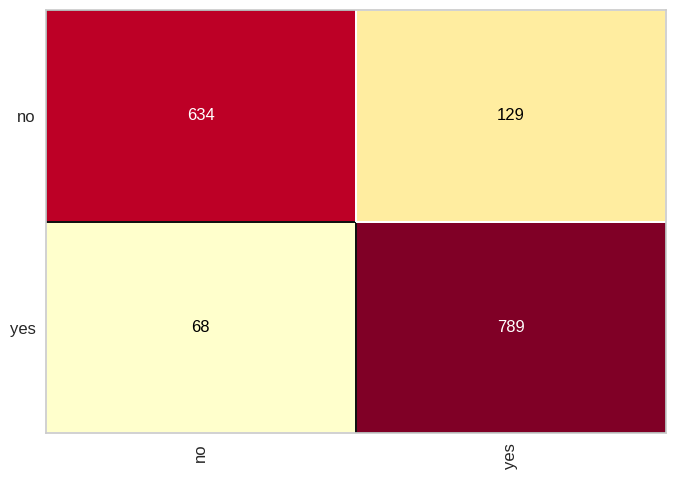

In [64]:
cm = ConfusionMatrix(modelo, force_model=True)
cm.fit(X_treino_final, y_treino)
cm.score(X_teste_final, y_teste)


In [65]:
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

          no       0.90      0.83      0.87       763
         yes       0.86      0.92      0.89       857

    accuracy                           0.88      1620
   macro avg       0.88      0.88      0.88      1620
weighted avg       0.88      0.88      0.88      1620



**Combinando dados tabulares + dados textuais**

In [66]:
base

,Verified,Month Flown,Class,Seat Comfort,Staff Service,Food & Beverages,Inflight Entertainment,Value For Money,Overall Rating,Recommended,...,Route_İstanbul to Frankfurt,Route_İstanbul to Hamburg,Route_İstanbul to Islamabad,Route_İstanbul to Izmir,Route_İstanbul to Tel Aviv-Yafo,Route_İzmir to İstanbul,Type of Traveller_Couple Leisure,Type of Traveller_Family Leisure,Type of Traveller_Solo Leisure,Texto_Completo
0,0,1,2,4,4,4,4,4,9,yes,...,0,0,0,0,0,0,0,0,1,flight amazing flight amazing crew onboard fli...
1,0,0,4,5,3,4,4,1,3,no,...,0,0,0,0,0,0,0,0,1,seat aircraft dreadful booking emergency exit ...
2,0,0,4,1,5,2,1,5,10,yes,...,0,0,0,0,0,0,0,1,0,food plentiful tasty excellent performance fro...
3,0,0,4,5,5,5,5,5,10,yes,...,0,0,0,0,0,0,0,0,1,much food available pretty comfortable flight ...
4,0,0,4,5,5,5,5,5,10,yes,...,0,0,0,0,0,0,0,1,0,service consistently good service consistently...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8095,0,0,4,5,4,5,3,4,7,yes,...,0,0,0,0,0,0,0,0,0,uneventful flight ke124 brisbane incheon a330 ...
8096,0,0,4,3,5,5,4,5,10,yes,...,0,0,0,0,0,0,1,0,0,korean air always impress recent flight fourth...
8097,0,0,2,4,5,5,5,1,2,no,...,0,0,0,0,0,0,0,0,0,didnt offer anything flew korean air bali seou...
8098,0,0,2,5,1,3,4,5,10,yes,...,0,0,0,0,0,0,0,0,0,appreciated service onboard seoul paris korean...


**Conjunto de treino e teste**

In [67]:
X = base.drop('Recommended', axis=1)

In [68]:
y_classe = base['Recommended'].values

In [69]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y_classe,
                                                      test_size=0.20,
                                                      random_state=42,
                                                      stratify=y_classe)

In [70]:
print("Tamanho do Treino:", X_treino.shape)
print("Tamanho do Teste:", X_teste.shape)

Tamanho do Treino: (6480, 5587)
Tamanho do Teste: (1620, 5587)


**Processamento do texto**

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    min_df=5  # Ignora palavras que aparecem em menos de 5 documentos (reduz ruído)
)

texto_treino_tfidf = tfidf.fit_transform(X_treino['Texto_Completo'])
texto_teste_tfidf = tfidf.transform(X_teste['Texto_Completo'])

print(f"Shape do Texto TF-IDF: {texto_treino_tfidf.shape}")

Shape do Texto TF-IDF: (6480, 1000)


In [72]:
# Normalizar atributo numérico
scaler = MinMaxScaler()
cols_to_scale = ['Seat Comfort', 'Staff Service', 'Food & Beverages', 'Inflight Entertainment', 'Value For Money', 'Overall Rating']
X_treino[cols_to_scale] = scaler.fit_transform(X_treino[cols_to_scale])
X_teste[cols_to_scale] = scaler.transform(X_teste[cols_to_scale])

In [73]:
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression

X_treino_numerical_categorical = X_treino.drop(columns=['Texto_Completo'], errors='ignore')
X_teste_numerical_categorical = X_teste.drop(columns=['Texto_Completo'], errors='ignore')

X_treino_final = hstack([texto_treino_tfidf, X_treino_numerical_categorical])
X_teste_final = hstack([texto_teste_tfidf, X_teste_numerical_categorical])

model_log = LogisticRegression(max_iter=1000, random_state=42)
model_log.fit(X_treino_final, y_treino)

tfidf_feature_names = tfidf.get_feature_names_out()

numerical_categorical_feature_names = X_treino_numerical_categorical.columns.tolist()

nomes_features = list(tfidf_feature_names) + numerical_categorical_feature_names

# Criar tabela de importância
df_pesos = pd.DataFrame({
    'Atributo': nomes_features,
    'Peso': model_log.coef_[0]
})

# Exibir
print("--- TOP 20 RECOMENDA (Pesos positivos) ---")
print(df_pesos.sort_values(by='Peso', ascending=False).head(20))

print("\n--- TOP 20 NÃO RECOMENDA (Pesos negativos) ---")
print(df_pesos.sort_values(by='Peso', ascending=True).head(20))

--- TOP 20 RECOMENDA (Pesos positivos) ---
                                Atributo      Peso
1008                      Overall Rating  6.442994
1007                     Value For Money  3.956373
394                                 good  1.598570
315                            excellent  1.544549
943                                usual  1.327994
354                               flight  1.298257
375                             friendly  1.210832
396                                great  1.198360
294                            efficient  1.195767
625                              overall  1.130960
1208                Route_Athens to Doha  1.076930
132                            breakfast  1.070407
473                                  jfk  1.025258
293                              economy  1.003649
5758         Route_Singapore to Brisbane  0.986274
426                                 hope  0.973994
39                              aircraft  0.961938
549                                 mas

In [74]:
print(f"Shape Final Treino: {X_treino_final.shape}")
print(f"Shape Final Teste: {X_teste_final.shape}")

Shape Final Treino: (6480, 6586)
Shape Final Teste: (1620, 6586)


**Random Forest para avaliar resultado**

In [80]:
from sklearn.ensemble import RandomForestClassifier
modelo = RandomForestClassifier(n_estimators=100, max_features='log2', criterion='gini', random_state = 42)
modelo.fit(X_treino_final, y_treino)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [81]:
previsoes = modelo.predict(X_teste_final)

In [82]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_score(y_teste,previsoes)

0.8975308641975308

In [83]:
from yellowbrick.classifier import ConfusionMatrix
confusion_matrix(y_teste, previsoes)

array([[651, 112],
       [ 54, 803]])

0.8975308641975308

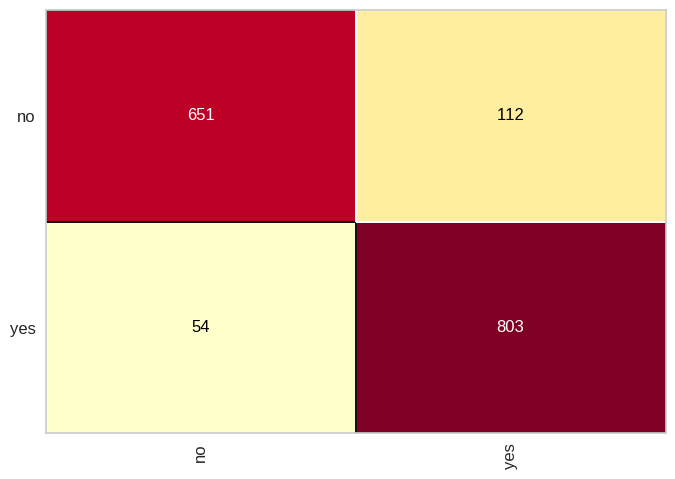

In [86]:
cm = ConfusionMatrix(modelo, force_model=True)
cm.fit(X_treino_final, y_treino)
cm.score(X_teste_final, y_teste)

In [87]:
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

          no       0.92      0.85      0.89       763
         yes       0.88      0.94      0.91       857

    accuracy                           0.90      1620
   macro avg       0.90      0.90      0.90      1620
weighted avg       0.90      0.90      0.90      1620

